In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.home() / "Documents" / "spotify_project"

CLEAN_DATA = PROJECT_ROOT / "data" / "clean"
FIGURES = PROJECT_ROOT / "figures"

In [2]:
df = pd.read_csv(CLEAN_DATA / "spotify_final.csv")

In [3]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (8775, 16)


,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min,release_year
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,False,Britney Spears,80.0,17755451.0,pop,325wcm5wMnlfjmKZ8PXIIn,The Singles Collection,2009-11-09,58,compilation,3.55,2009
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,False,BUNT.,69.0,293734.0,stutter house,2ArRQNLxf9t0O0gvmG5Vsj,Clouds,2023-01-13,1,single,2.65,2023
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,False,Taylor Swift,100.0,145396321.0,NaN,4hDok0OAJd57SGIT8xuWJH,Fearless (Taylor's Version),2021-04-09,26,album,3.76,2021
3,7bcy34fBT2ap1L4bfPsl9q,I Didn't Change My Number,2,72,True,Billie Eilish,90.0,118692183.0,NaN,0JGOiO34nwfUdDrD612dOp,Happier Than Ever,2021-07-30,16,album,2.64,2021
4,0GLfodYacy3BJE7AI3A8en,Man Down,7,57,False,Rihanna,90.0,68997177.0,NaN,5QG3tjE5L9F6O2vCAPph38,Loud,2010-01-01,13,album,4.45,2010


In [4]:
print("Total tracks:", len(df))
print("Unique artists:", df["artist_name"].nunique())
print("Unique albums:", df["album_id"].nunique())
print("Release years:", df["release_year"].min(), "to", df["release_year"].max())

Total tracks: 8775
Unique artists: 2546
Unique albums: 5314
Release years: 1952 to 2025


In [5]:
df["track_popularity"].describe()

count    8775.000000
mean       52.250712
std        24.059952
min         0.000000
25%        39.000000
50%        58.000000
75%        71.000000
max       100.000000
Name: track_popularity, dtype: float64

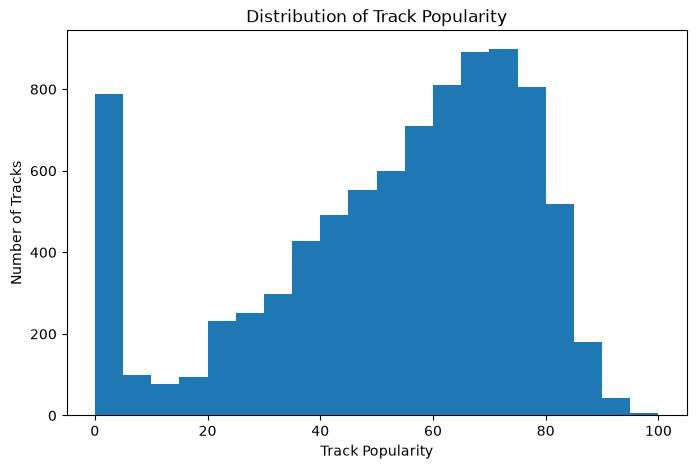

In [6]:
plt.figure(figsize=(8, 5))

plt.hist(df["track_popularity"], bins=20)

plt.title("Distribution of Track Popularity")
plt.xlabel("Track Popularity")
plt.ylabel("Number of Tracks")

plt.show()

In [7]:
df["artist_popularity"].describe()

count    8772.000000
mean       69.980506
std        19.500541
min         0.000000
25%        60.000000
50%        74.000000
75%        84.000000
max       100.000000
Name: artist_popularity, dtype: float64

In [8]:
correlation = df["artist_popularity"].corr(df["track_popularity"])

print("Correlation:", round(correlation, 2))

Correlation: 0.45


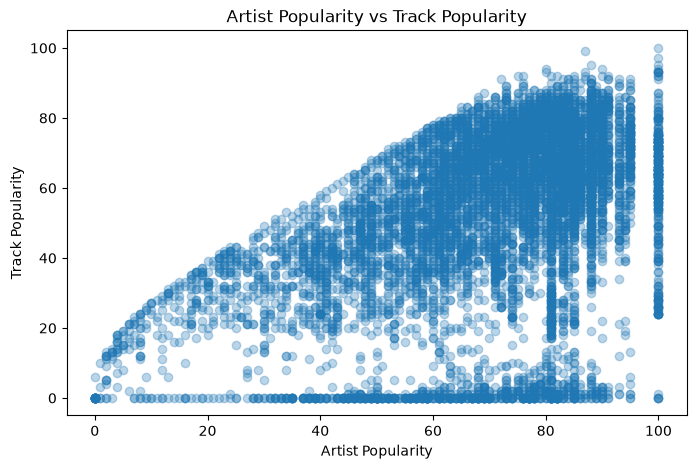

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["artist_popularity"],
    df["track_popularity"],
    alpha=0.3
)

plt.title("Artist Popularity vs Track Popularity")
plt.xlabel("Artist Popularity")
plt.ylabel("Track Popularity")

plt.show()

In [10]:
df["artist_followers"].describe()

count    8.772000e+03
mean     2.437636e+07
std      3.816164e+07
min      0.000000e+00
25%      5.160382e+05
50%      6.294820e+06
75%      3.055207e+07
max      1.455421e+08
Name: artist_followers, dtype: float64

In [11]:
correlation = df["artist_followers"].corr(df["track_popularity"])

print("Correlation:", round(correlation, 2))

Correlation: 0.23


In [12]:
correlation = df["track_duration_min"].corr(df["track_popularity"])

print("Correlation:", round(correlation, 2))

Correlation: 0.1


In [13]:
df.groupby("explicit")["track_popularity"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
explicit,,,
False,6584,50.49,55.0
True,2191,57.54,64.0


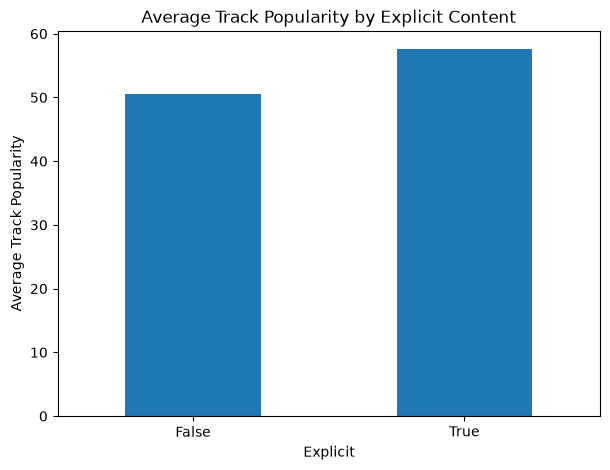

In [14]:
explicit_popularity = df.groupby("explicit")["track_popularity"].mean()

explicit_popularity.plot(kind="bar", figsize=(7, 5))

plt.title("Average Track Popularity by Explicit Content")
plt.xlabel("Explicit")
plt.ylabel("Average Track Popularity")
plt.xticks(rotation=0)

plt.show()

In [15]:
df.groupby("album_type")["track_popularity"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
album_type,,,
album,6022,55.53,61.0
compilation,508,40.51,44.0
single,2245,46.11,51.0


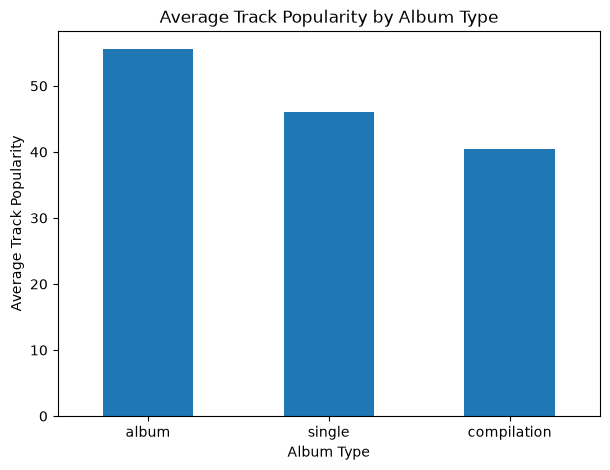

In [16]:
album_popularity = (
    df.groupby("album_type")["track_popularity"]
    .mean()
    .sort_values(ascending=False)
)

album_popularity.plot(kind="bar", figsize=(7, 5))

plt.title("Average Track Popularity by Album Type")
plt.xlabel("Album Type")
plt.ylabel("Average Track Popularity")
plt.xticks(rotation=0)

plt.show()

In [17]:
tracks_by_year = df.groupby("release_year").size()

tracks_by_year.tail(15)

release_year
2011    271
2012    336
2013    316
2014    353
2015    405
2016    388
2017    473
2018    534
2019    500
2020    493
2021    448
2022    475
2023    526
2024    658
2025    768
dtype: int64

In [18]:
popularity_by_year = (
    df.groupby("release_year")["track_popularity"]
    .mean()
    .round(2)
)

popularity_by_year.tail(15)

release_year
2011    50.04
2012    51.49
2013    49.96
2014    52.70
2015    53.22
2016    50.72
2017    50.80
2018    53.43
2019    53.57
2020    50.77
2021    52.42
2022    50.34
2023    52.19
2024    53.76
2025    51.89
Name: track_popularity, dtype: float64

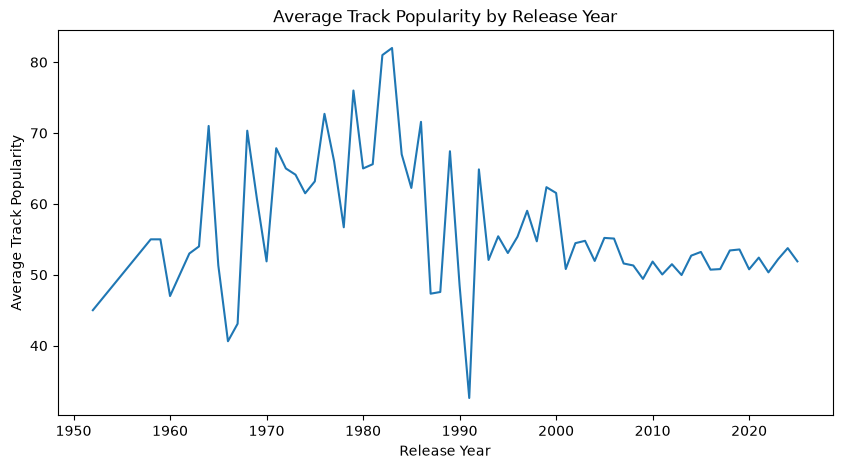

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    popularity_by_year.index,
    popularity_by_year.values
)

plt.title("Average Track Popularity by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Track Popularity")

plt.show()

In [20]:
tracks_by_year.head(20)

release_year
1952     1
1958     1
1959     5
1960     1
1962     5
1963     1
1964     1
1965     3
1966     8
1967    11
1968     3
1969    17
1970     9
1971     7
1972     4
1973    16
1974     2
1975    11
1976     7
1977     9
dtype: int64

In [21]:
valid_years = tracks_by_year[
    tracks_by_year >= 30
].index

popularity_by_valid_year = (
    df[df["release_year"].isin(valid_years)]
    .groupby("release_year")["track_popularity"]
    .mean()
    .round(2)
)

print("First year:", popularity_by_valid_year.index.min())
print("Last year:", popularity_by_valid_year.index.max())
print("Number of years:", len(popularity_by_valid_year))

First year: 1987
Last year: 2025
Number of years: 33


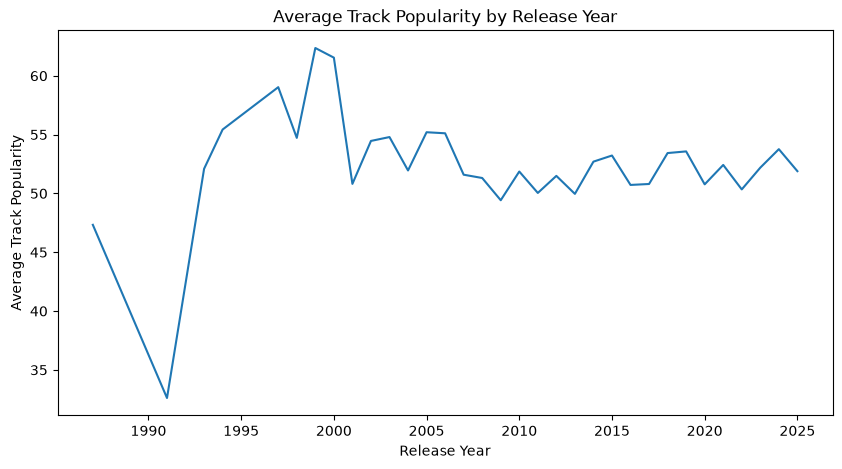

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(
    popularity_by_valid_year.index,
    popularity_by_valid_year.values
)

plt.title("Average Track Popularity by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Track Popularity")

plt.show()

In [23]:
top_tracks = df[
    [
        "track_name",
        "artist_name",
        "track_popularity",
        "album_name",
        "release_year"
    ]
].sort_values(
    "track_popularity",
    ascending=False
).head(10)

top_tracks

,track_name,artist_name,track_popularity,album_name,release_year
7090,The Fate of Ophelia,Taylor Swift,100,The Life of a Showgirl,2025
4370,Golden,HUNTR/X,99,KPop Demon Hunters (Soundtrack from the Netfli...,2025
5494,Opalite,Taylor Swift,97,The Life of a Showgirl,2025
3634,Man I Need,Olivia Dean,95,Man I Need,2025
6448,Elizabeth Taylor,Taylor Swift,95,The Life of a Showgirl,2025
1390,BIRDS OF A FEATHER,Billie Eilish,94,HIT ME HARD AND SOFT,2024
3125,Soda Pop,Saja Boys,94,KPop Demon Hunters (Soundtrack from the Netfli...,2025
8656,Father Figure,Taylor Swift,94,The Life of a Showgirl,2025
2829,CANCELLED!,Taylor Swift,93,The Life of a Showgirl,2025
2556,Actually Romantic,Taylor Swift,93,The Life of a Showgirl,2025


In [24]:
artist_summary = df.groupby("artist_name").agg(
    track_count=("track_id", "count"),
    average_popularity=("track_popularity", "mean")
)

top_artists = artist_summary[
    artist_summary["track_count"] >= 5
].sort_values(
    "average_popularity",
    ascending=False
).head(10)

top_artists.round(2)

,track_count,average_popularity
artist_name,,
Alex Warren,5,83.40
Red Hot Chili Peppers,9,80.89
Arctic Monkeys,10,79.80
sombr,15,79.67
Benson Boone,7,79.00
Sabrina Carpenter,37,77.95
XXXTENTACION,8,77.75
Gracie Abrams,8,76.38
Tame Impala,13,75.00


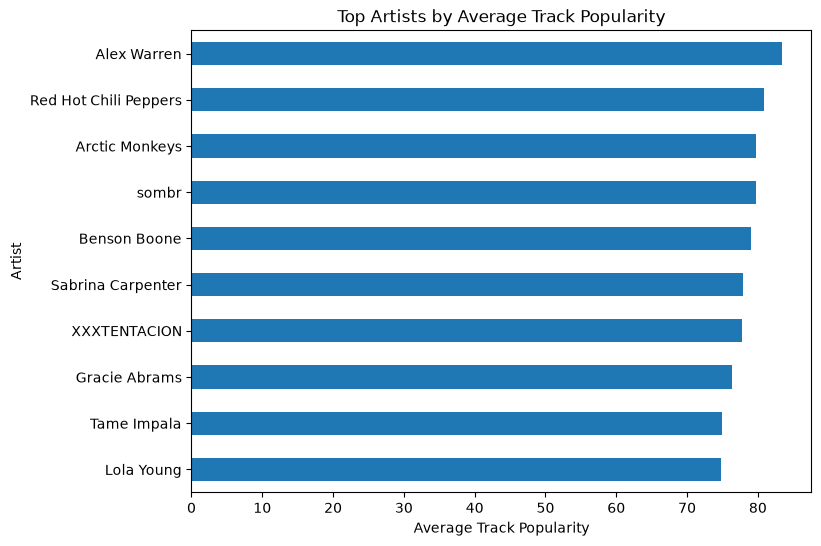

In [25]:
top_artists_sorted = top_artists.sort_values("average_popularity")

top_artists_sorted["average_popularity"].plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("Top Artists by Average Track Popularity")
plt.xlabel("Average Track Popularity")
plt.ylabel("Artist")

plt.show()

In [26]:
df_genres = df.dropna(subset=["artist_genres"]).copy()

df_genres["genre"] = df_genres["artist_genres"].str.split(", ")

df_genres = df_genres.explode("genre")

In [27]:
df_genres[["track_name", "artist_name", "genre"]].head(10)

,track_name,artist_name,genre
0,3,Britney Spears,pop
1,Clouds,BUNT.,stutter house
5,Space Song,Beach House,dream pop
7,Allein Allein - BENNETT Remix,Alok,brazilian bass
7,Allein Allein - BENNETT Remix,Alok,electronic
7,Allein Allein - BENNETT Remix,Alok,slap house
7,Allein Allein - BENNETT Remix,Alok,electro house
8,Even My Dad Does Sometimes,Ed Sheeran,soft pop
10,Wide Awake,Katy Perry,pop
11,Doja,Central Cee,uk drill


In [28]:
genre_counts = (
    df_genres["genre"]
    .value_counts()
    .head(15)
)

genre_counts

genre
soundtrack      451
pop             387
rap             304
country         277
rock            270
soft pop        224
art pop         181
hip hop         149
nu metal        123
dark r&b        119
edm             112
grunge          104
classic rock    104
egyptian pop    102
latin            98
Name: count, dtype: int64

In [29]:
genre_summary = df_genres.groupby("genre").agg(
    track_count=("track_id", "count"),
    average_popularity=("track_popularity", "mean")
)

top_genres = genre_summary[
    genre_summary["track_count"] >= 30
].sort_values(
    "average_popularity",
    ascending=False
).head(10)

top_genres.round(2)


,track_count,average_popularity
genre,,
trap latino,64,73.53
urbano latino,74,73.05
reggaeton,86,71.26
post-grunge,36,69.78
indie,54,68.74
gangster rap,33,68.09
latin,98,67.47
west coast hip hop,40,66.78
hyperpop,34,66.35


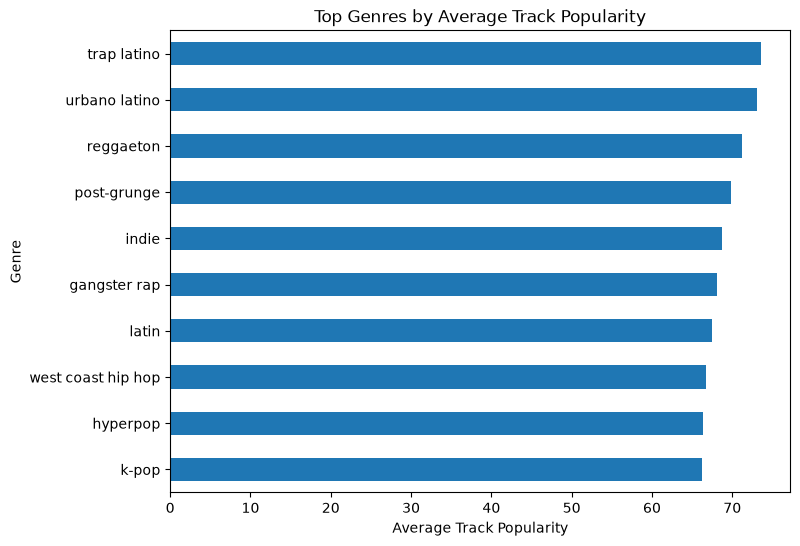

In [30]:
top_genres_sorted = top_genres.sort_values("average_popularity")

top_genres_sorted["average_popularity"].plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("Top Genres by Average Track Popularity")
plt.xlabel("Average Track Popularity")
plt.ylabel("Genre")

plt.show()

In [31]:
df["duration_group"] = pd.cut(
    df["track_duration_min"],
    bins=[0, 2, 4, 6, float("inf")],
    labels=["Short", "Standard", "Long", "Very Long"],
    right=False
)

In [32]:
df["duration_group"].value_counts().sort_index()

duration_group
Short         434
Standard     6146
Long         2026
Very Long     169
Name: count, dtype: int64

In [33]:
df.groupby(
    "duration_group",
    observed=True
)["track_popularity"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
duration_group,,,
Short,434,38.38,41.0
Standard,6146,52.61,59.0
Long,2026,54.53,60.0
Very Long,169,47.53,52.0


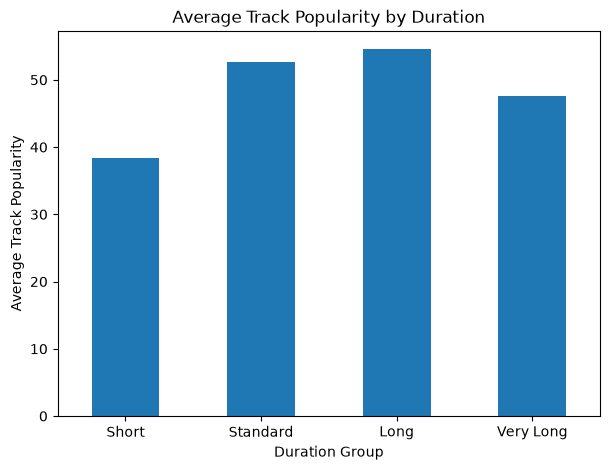

In [34]:
duration_popularity = (
    df.groupby("duration_group", observed=True)["track_popularity"]
    .mean()
)

duration_popularity.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Track Popularity by Duration")
plt.xlabel("Duration Group")
plt.ylabel("Average Track Popularity")
plt.xticks(rotation=0)

plt.show()

In [35]:
df["decade"] = (df["release_year"] // 10) * 10

In [36]:
df["decade"].value_counts().sort_index()

decade
1950       7
1960      50
1970      80
1980     100
1990     406
2000     937
2010    3827
2020    3368
Name: count, dtype: int64

In [37]:
decade_popularity = df.groupby("decade")["track_popularity"].agg(
    ["count", "mean", "median"]
).round(2)

decade_popularity

,count,mean,median
decade,,,
1950,7,53.57,58.0
1960,50,52.66,57.5
1970,80,63.70,72.0
1980,100,59.68,64.0
1990,406,51.05,58.0
2000,937,53.09,57.0
2010,3827,51.96,58.0
2020,3368,51.99,57.0


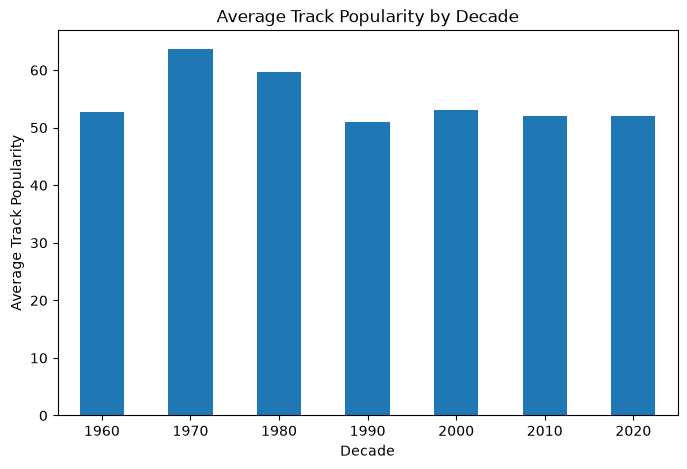

In [38]:
decade_chart = decade_popularity[
    decade_popularity["count"] >= 30
]

decade_chart["mean"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Track Popularity by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Track Popularity")
plt.xticks(rotation=0)

plt.show()

In [39]:
df["album_total_tracks"].describe()

count    8775.000000
mean       13.783362
std        11.798278
min         1.000000
25%         6.000000
50%        13.000000
75%        17.000000
max       181.000000
Name: album_total_tracks, dtype: float64

In [40]:
df["album_size_group"] = pd.cut(
    df["album_total_tracks"],
    bins=[0, 5, 12, 20, float("inf")],
    labels=["Small", "Medium", "Large", "Very Large"]
)

In [41]:
df["album_size_group"].value_counts().sort_index()

album_size_group
Small         2147
Medium        1961
Large         3251
Very Large    1416
Name: count, dtype: int64

In [42]:
df.groupby(
    "album_size_group",
    observed=True
)["track_popularity"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
album_size_group,,,
Small,2147,46.01,50.0
Medium,1961,56.34,63.0
Large,3251,56.15,62.0
Very Large,1416,47.09,49.0


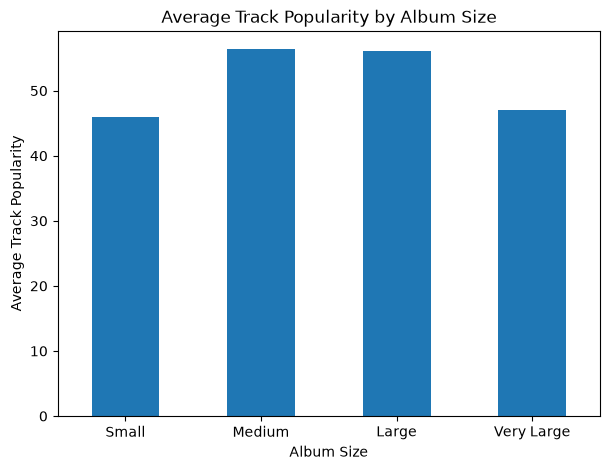

In [43]:
album_size_popularity = (
    df.groupby("album_size_group", observed=True)["track_popularity"]
    .mean()
)

album_size_popularity.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Track Popularity by Album Size")
plt.xlabel("Album Size")
plt.ylabel("Average Track Popularity")
plt.xticks(rotation=0)

plt.show()

In [44]:
correlation = artist_summary["track_count"].corr(
    artist_summary["average_popularity"]
)

print("Correlation:", round(correlation, 2))

Correlation: 0.09


In [45]:
df["popularity_group"] = pd.cut(
    df["track_popularity"],
    bins=[-1, 20, 40, 60, 80, 100],
    labels=["Very Low", "Low", "Moderate", "High", "Very High"]
)

In [46]:
df["popularity_group"].value_counts().sort_index()

popularity_group
Very Low     1096
Low          1270
Moderate     2392
High         3398
Very High     619
Name: count, dtype: int64

In [47]:
popularity_percentage = (
    df["popularity_group"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

popularity_percentage


popularity_group
Very Low     12.49
Low          14.47
Moderate     27.26
High         38.72
Very High     7.05
Name: proportion, dtype: float64

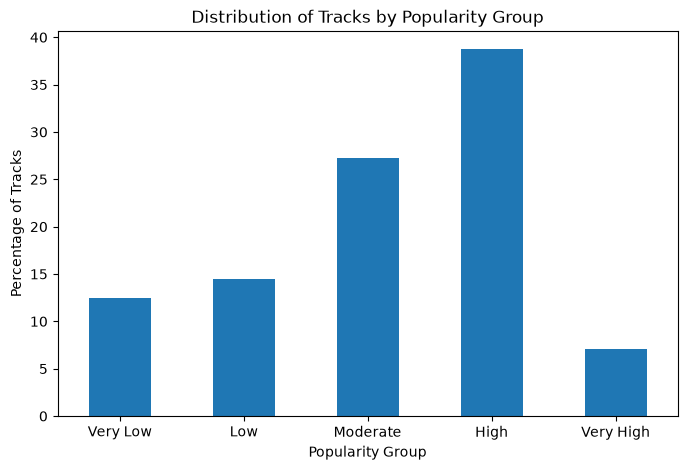

In [48]:
popularity_percentage.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of Tracks by Popularity Group")
plt.xlabel("Popularity Group")
plt.ylabel("Percentage of Tracks")
plt.xticks(rotation=0)

plt.show()

In [ ]:
## Key EDA Findings

#1. The cleaned dataset contains 8,775 tracks from 2,546 artists and 5,314 albums, covering releases from 1952 to 2025.

#2. Average track popularity is 52.25, with a median of 58.

#3. Artist popularity has a moderate positive relationship with track popularity, with a correlation of 0.45.

#4. Artist follower count has only a weak positive relationship with track popularity, with a correlation of 0.23.

#5. Track duration has very little linear relationship with popularity, with a correlation of 0.10.

#6. Explicit tracks have higher average popularity at 57.54 compared with 50.49 for non explicit tracks.

#7. Album tracks have the highest average popularity at 55.53, compared with 46.11 for singles and 40.51 for compilations.

#8. Recent release years show relatively stable average popularity. Earlier yearly results are less reliable because of smaller sample sizes.

#9. Among artists represented by at least five tracks, Alex Warren has the highest average track popularity at 83.40.

#10. Latin urban genres perform strongly. Trap latino, urbano latino, and reggaeton have the highest average popularity among genres represented by at least 30 tracks.

#11. Tracks between 2 and 6 minutes generally have higher average popularity than very short or very long tracks.

#12. Tracks from releases containing 6 to 20 tracks have higher average popularity than tracks from very small or very large releases.

#13. The number of tracks represented per artist has almost no relationship with average popularity, with a correlation of 0.09.

#4. High popularity is the largest popularity group at 38.72 percent of tracks. High and Very High tracks together account for 45.77 percent of the dataset.